# **Web Scraping**


## Objectives


* Extract information from a given web site 
* Write the scraped data into a csv file.


## Extract information from the given web site



In [1]:
#this url contains the data you need to scrape
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

The data we need to scrape is the **name of the programming language** and **average annual salary**.


Import the required libraries


In [2]:
from bs4 import BeautifulSoup
import requests

Download the webpage at the url


In [3]:
data = requests.get(url).text

Create a soup object


In [4]:
soup = BeautifulSoup(data,"html.parser")

Scrape the `Language name` and `annual average salary`.  Save the scrapped data into a file named popular-languages.csv


In [5]:
import csv
table = soup.find('table') # in html table is represented by the tag <table>
with open("popular-languages.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Language_name", "annual_average_salary"])

    for row in table.find_all('tr')[1:]:  # skip header
        cols = row.find_all('td')
        if len(cols) >= 4:
            Language_name = cols[1].getText().strip()
            annual_average_salary = cols[3].getText().strip()
            writer.writerow([Language_name, annual_average_salary])

print("Data saved to popular-languages.csv")

Data saved to popular-languages.csv


In [6]:
import os

print("Current working directory:", os.getcwd())

Current working directory: C:\Users\ḥ\Downloads


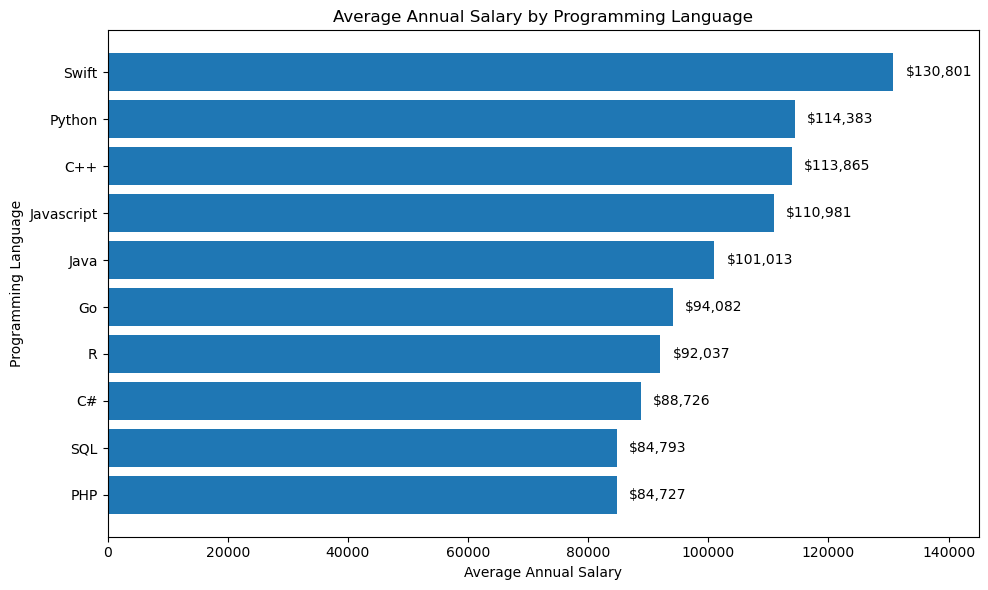

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv("popular-languages.csv")

# Remove $ and commas, then convert salary to numeric
df["annual_average_salary"] = (
    df["annual_average_salary"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(int)
)

# Sort salary in descending order
df = df.sort_values(
    by="annual_average_salary",
    ascending=False
)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

bars = plt.barh(
    df["Language_name"],
    df["annual_average_salary"]
)

# Highest salary at top
plt.gca().invert_yaxis()

# Add salary labels
for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 2000,
        bar.get_y() + bar.get_height()/2,
        f"${value:,.0f}",
        va="center"
    )

plt.xlabel("Average Annual Salary")
plt.ylabel("Programming Language")
plt.title("Average Annual Salary by Programming Language")

plt.xlim(0, 145000)

plt.tight_layout()
plt.show()